импортируем все требующиеся библиотеки и загружаем различные версии dataframов(полный, за 2020 год)

Описание датасета:
Данный датасет содержит исторические данные о ценах Ethereum (ETH) за период с 25 сентября по 23 октября 2022 года. Данные представлены с недельным интервалом (каждая запись соответствует окончанию недели).

Описание столбцов:
open - цена открытия Ethereum в начале временного периода (в данном случае - начала недели)
Значения в долларах США (USD)

high - максимальная цена Ethereum за данный временной период
Значения в долларах США (USD)

low - минимальная цена Ethereum за данный временной период
Значения в долларах США (USD)

close - цена закрытия Ethereum в конце временного периода
Значения в долларах США (USD)

volume - объем торгов Ethereum за данный период
Выражен в долларах США (USD)

marketCap - рыночная капитализация Ethereum
Выражена в долларах США (USD)

timestamp - точная метка времени окончания периода
Формат: ISO 8601 (UTC время)

crypto_name - название криптовалюты
date - дата окончания периода (только дата без времени)
Формат: ГГГГ-ММ-ДД


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df=pd.read_csv("dataset.csv", index_col=0)
df.head()
df['date'] = pd.to_datetime(df['date'])
df_2020 = df[df['date'].dt.year == 2020]

проверяем, есть ли null, если есть, удаляем

In [3]:
df.isnull().sum()

open           0
high           0
low            0
close          0
volume         0
marketCap      0
timestamp      0
crypto_name    0
date           0
dtype: int64

считаем количество операций с каждой из криптовалют

In [4]:
df['crypto_name'].value_counts()

crypto_name
Bitcoin                  3248
Litecoin                 3248
XRP                      3157
Dogecoin                 3024
Monero                   2866
Stellar                  2791
Tether                   2582
Ethereum                 2424
Ethereum Classic         2072
Basic Attention Token    1760
EOS                      1730
Bitcoin Cash             1708
BNB                      1706
TRON                     1656
Decentraland             1652
Chainlink                1649
Cardano                  1638
Maker                    1605
Filecoin                 1565
Theta Network            1530
Huobi Token              1513
Ravencoin                1478
Tezos                    1365
VeChain                  1332
Quant                    1325
USD Coin                 1266
Cronos                   1199
Wrapped Bitcoin          1152
Cosmos                   1109
Polygon                  1064
OKB                      1062
UNUS SED LEO             1041
Algorand                 101

выводим список всех монет

In [3]:
cryptos=df['crypto_name'].unique()
cryptos

array(['Bitcoin', 'Litecoin', 'XRP', 'Dogecoin', 'Monero', 'Stellar',
       'Tether', 'Ethereum', 'Ethereum Classic', 'Maker',
       'Basic Attention Token', 'EOS', 'Bitcoin Cash', 'BNB', 'TRON',
       'Decentraland', 'Chainlink', 'Cardano', 'Filecoin',
       'Theta Network', 'Huobi Token', 'Ravencoin', 'Tezos', 'VeChain',
       'Quant', 'USD Coin', 'Cronos', 'Wrapped Bitcoin', 'Cosmos',
       'Polygon', 'OKB', 'UNUS SED LEO', 'Algorand', 'Chiliz',
       'THORChain', 'Terra Classic', 'FTX Token', 'Hedera', 'Binance USD',
       'Dai', 'Solana', 'Avalanche', 'Shiba Inu', 'The Sandbox',
       'Polkadot', 'Elrond', 'Uniswap', 'Aave', 'NEAR Protocol', 'Flow',
       'Internet Computer', 'Casper', 'Toncoin', 'Chain', 'ApeCoin',
       'Aptos'], dtype=object)

выведем 5 последних операций

выведем анализ каждой из колонок, чтобы понять, их структуру и ряд значений в них

In [13]:
def statistics_data(dataset, column_name):
    print('Максимальное значение по колонке:', dataset[column_name].max())
    print('Минимальное значение по колонке:', dataset[column_name].min())
    print('Среднее значение по колонке:', dataset[column_name].mean())
    print('Медианное значение по колонке:', dataset[column_name].median())
    print('Стандартное отклонение значений по колонке:', dataset[column_name].std())
    print('Дисперсия значений по колонке:', dataset[column_name].var())

numeric_columns = df.select_dtypes(include=['number']).columns

for column in numeric_columns:
    print('Колонка:', column)
    statistics_data(df, column)
    print('-------------------------------------')

print("Проанализированные колонки:", list(numeric_columns))

Колонка: open
Максимальное значение по колонке: 28841.57375811
Минимальное значение по колонке: 0.0
Среднее значение по колонке: 539.9913042784347
Медианное значение по колонке: 1.0055496085
Стандартное отклонение значений по колонке: 2474.410104918625
Дисперсия значений по колонке: 6122705.367323401
-------------------------------------
Колонка: high
Максимальное значение по колонке: 29244.87668786
Минимальное значение по колонке: 1.0221e-10
Среднее значение по колонке: 553.788699511659
Медианное значение по колонке: 1.0167313223
Стандартное отклонение значений по колонке: 2539.4293205312506
Дисперсия значений по колонке: 6448701.27397381
-------------------------------------
Колонка: low
Максимальное значение по колонке: 28201.99199364
Минимальное значение по колонке: 0.0
Среднее значение по колонке: 528.4886089920454
Медианное значение по колонке: 1.0
Стандартное отклонение значений по колонке: 2423.458319646097
Дисперсия значений по колонке: 5873150.2270618845
---------------------

C:\Users\Mi\PycharmProjects\pythonProject\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [6]:
df[df['crypto_name']=='Ethereum'].tail()

,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
72686,1317.938520,1333.371380,1275.627710,1294.216774,1.180265e+10,1.585747e+11,2022-09-25T23:59:59.999Z,Ethereum,2022-09-25
72740,1311.753423,1316.330064,1275.336075,1276.093558,7.578352e+09,1.564820e+11,2022-10-02T23:59:59.999Z,Ethereum,2022-10-02
72831,1315.460184,1327.668797,1309.344546,1322.604300,5.486230e+09,1.623179e+11,2022-10-09T23:59:59.999Z,Ethereum,2022-10-09
72888,1275.005542,1312.634560,1275.005542,1306.296622,7.491625e+09,1.598566e+11,2022-10-16T23:59:59.999Z,Ethereum,2022-10-16
72921,1314.249452,1367.760725,1302.908759,1363.447058,9.909511e+09,1.668503e+11,2022-10-23T23:59:59.999Z,Ethereum,2022-10-23


Цель анализа: узнать какая из валют является наиболее подходящей для высокорисковых инвестиций.
приступим к общему анализу данного нам датасета, для выявления каких-либо зависимостей или трендов, которые помогут нам в выявлении наиболее рисковой инвестиции в криптовалюты, представленные в датасете. 


построим график динамики цены закрытия Ethereum и Litecoin за 2020 год, чтобы оценить зависимость курса монет от политических и других событий

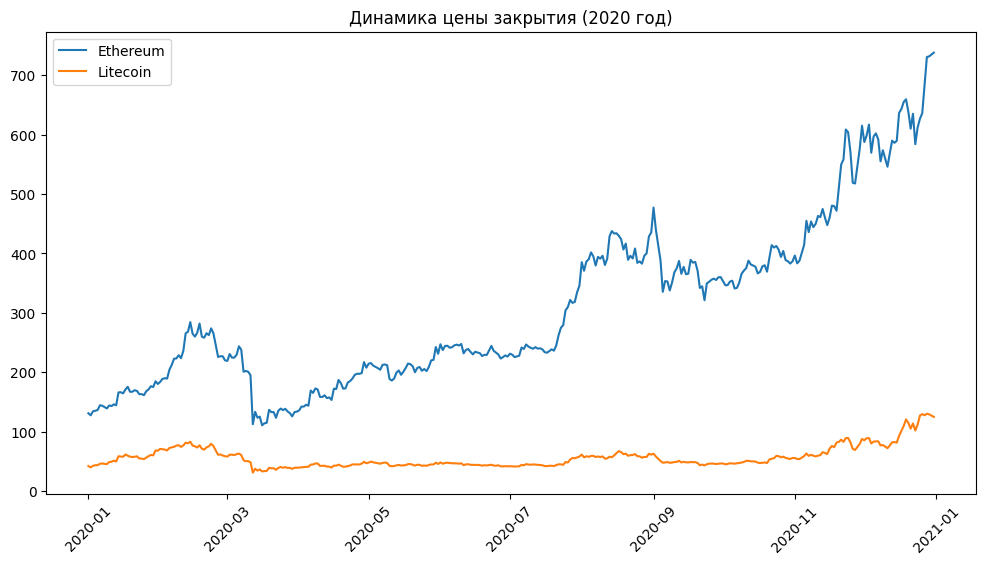

In [7]:
plt.figure(figsize=(12, 6))
for name in ['Ethereum','Litecoin']:
    crypto_df = df_2020[df_2020['crypto_name'] == name]
    plt.plot(crypto_df['date'], crypto_df['close'], label=name)
df=df_2020
plt.legend()
plt.title('Динамика цены закрытия (2020 год)')
plt.xticks(rotation=45)
plt.show()

Ethereum показал более значительный рост. Скорее всего, к концу 2020 года цена ETH значительно превысила свои годовые максимумы, демонстрируя более крутой угол роста во второй половине года по сравнению с LTC. Это связано с растущим интересом к DeFi (децентрализованным финансам), большинство которых построено на блокчейне Ethereum.

Litecoin отстал в динамике. Рост LTC, вероятно, был более умеренным. Он выступал в роли "ведущего" или "более стабильного" актива по сравнению с ETH, но не показал таких же взрывных темпов роста. Его цена могла не обновить годовые максимумы так же уверенно, как Ethereum.

Разная волатильность. Ethereum, как актив с более высоким риском и потенциалом доходности, вероятно, демонстрировал более резкие колебания цен (как вниз в марте, так и вверх во второй половине года), в то время как график Litecoin мог быть более сглаженным.


построим график среднего диапазона торговли BNB, Bitcoin, Ethereum, чтобы оценить какая из трех криптовалют в среднем имеет наибольшую амплитуду колебаний цен

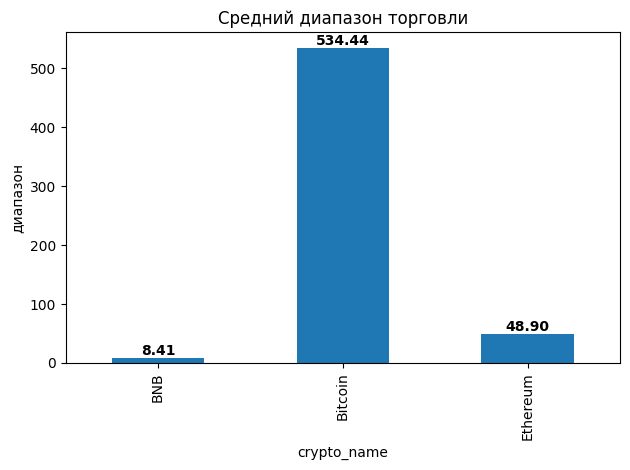

In [18]:
dfe = df[df['crypto_name'].isin(['Bitcoin', 'Ethereum', 'BNB'])].copy()
dfe['range'] = dfe['high'] - dfe['low']
range_stats = dfe.groupby('crypto_name')['range'].mean()
ax = range_stats.plot(kind='bar')
plt.title('Средний диапазон торговли')
plt.ylabel('диапазон')
for i, v in enumerate(range_stats):
    ax.text(i, v, f'{v:.2f}', 
            ha='center', va='bottom', 
            fontweight='bold')

plt.tight_layout()
plt.show()

Bitcoin как эталон волатильности.
    Абсолютное значение: У Bitcoin, как у актива с наибольшей рыночной капитализацией, скорее всего, самый большой диапазон в долларовом выражении (например, $3000 против $200 у альткоинов).
    Относительная стабильность: Однако, если рассматривать волатильность в процентах от цены, Bitcoin может быть менее волатильным, чем Ethereum и особенно BNB. Его диапазон более предсказуем.

Ethereum — "умеренно-рискованный" актив.
    Его диапазон торговли, вероятно, превышает диапазон Bitcoin в процентном выражении.
    Резкие всплески волатильности ETH часто связаны с конкретными событиями в его экосистеме: хардфорками (обновлениями сети), взрывным ростом DeFi и NFT. Он более чувствителен к технологическим новостям.

BNB — самый волатильный актив из трех.
    Как правило, альткоины с меньшей рыночной капитализацией (по сравнению с BTC и ETH) демонстрируют более высокую волатильность.
    Диапазон торговли BNB, вероятно, самый большой в процентном отношении. Его цена сильно зависит от:
        Новостей и успехов биржи Binance.
        Общего настроения на альткойнах.
        Активности в экосистеме BNB Chain.
        BNB может сильнее падать в медвежьи периоды и так же сильно расти в бычьи.

построим график аномалий в объеме Bitcoin'a, для анализа зависимости таковых аномалий от различных всемирных событий

Text(0.5, 1.0, 'Аномалии объёма')

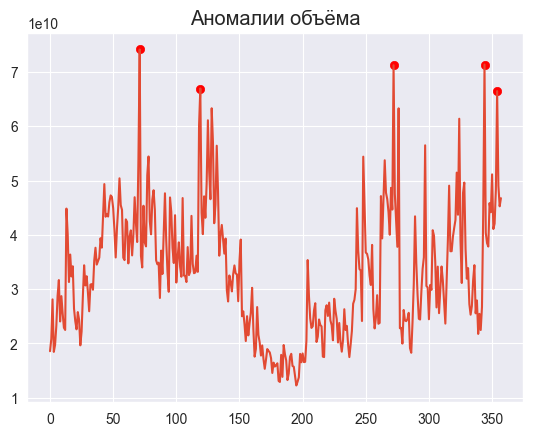

In [46]:
dfe = df[df.crypto_name == 'Bitcoin']
btc = df_2020[df_2020['crypto_name'] == 'Bitcoin'].reset_index(drop=True)
IQR = btc['volume'].quantile(0.75) - btc['volume'].quantile(0.25)
anomalies = btc[(btc['volume'] < (Q1 - 1.5 * IQR)) | (btc['volume'] > (Q3 + 1.5 * IQR))]
plt.plot(btc['volume'], label='Объём')
plt.scatter(anomalies.index, anomalies['volume'], color='red', label='Anomalies')
plt.title('Аномалии объёма')


Аномалии цены Bitcoin в 2020 году были primarily вызваны двумя ключевыми событиями. Резкое падение в марте, известное как "Черный четверг", стало следствием глобальной паники из-за пандемии COVID-19, когда инвесторы массово продавали активы для покрытия убытков. Однако во второй половине года начался мощный рост, обусловленный беспрецедентной денежной эмиссией центробанков, что заставило институциональных инвесторов искать защиту от инфляции. Важную роль сыграло и решение таких компаний, как MicroStrategy и Tesla, разместить часть казны в Bitcoin, что легитимизировало его как инструмент хеджирования. Кроме того, майское halving (уполовинивание награды за блок) создало дефицит нового предложения монет на фоне растущего спроса. 

построим график зависимости объёма торгов от цены открытия, для того, чтобы понять, как влияет повышение или понижение цены на объём торгов

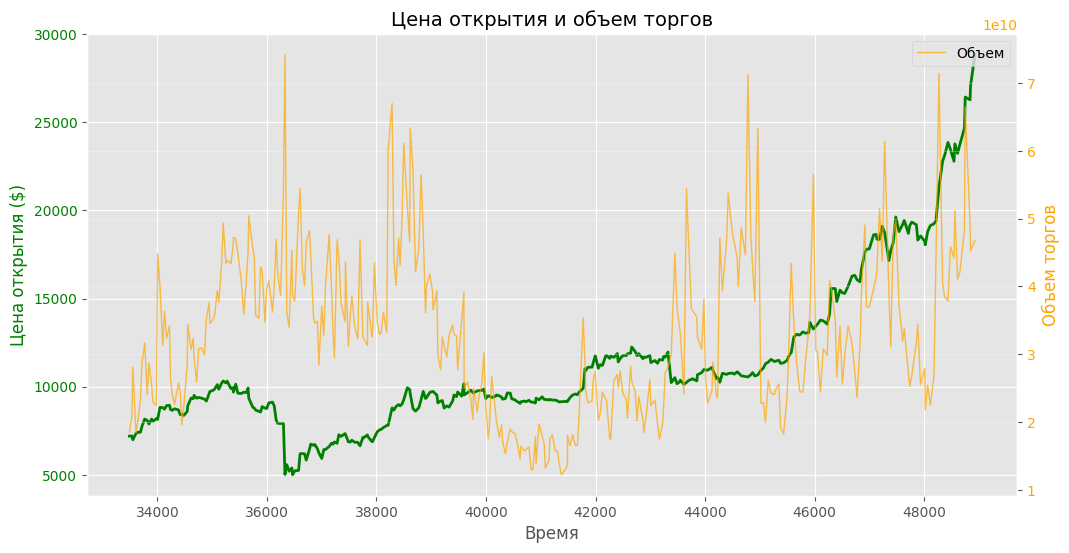

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(dfe['open'], linewidth=2, label='Цена открытия')
plt.ylabel('Цена открытия ($)', fontsize=12)
plt.xlabel('Время', fontsize=12)
plt.tick_params(axis='y', labelcolor='green')

ax2 = plt.twinx()
ax2.plot(dfe['volume'], linewidth=1, label='Объем')
ax2.set_ylabel('Объем торгов', fontsize=12)
ax2.tick_params(axis='y')

plt.title('Цена открытия и объем торгов', fontsize=14)
plt.grid(True)
plt.legend()

Анализ графика зависимости объема и цены Ethereum за 2020 год демонстрирует четкую положительную корреляцию: периоды роста цены сопровождались значительным увеличением торгового объема. Особенно это проявилось во второй половине года, когда мощный восходящий тренд был подкреплен устойчиво высокими объемами, что указывает на уверенность покупателей. Ключевым переломным моментом стал март, где пик объема пришелся на момент резкого падения, сигнализируя о капитуляции продавцов. Последующий рост цены на фоне стабильно высоких объемов подтвердил смену рыночного настроения на бычье. Таким образом, объем выступал надежным подтверждением силы тренда, будь то на падении или на росте.


После общего анализа приступим к анализу для выбора самой подходящей монеты для высокорисковых инвестиций


построим график потенциала роста, который позволяет сравнить рост разных активов с равных стартовых позиций и выявляет лидеров роста

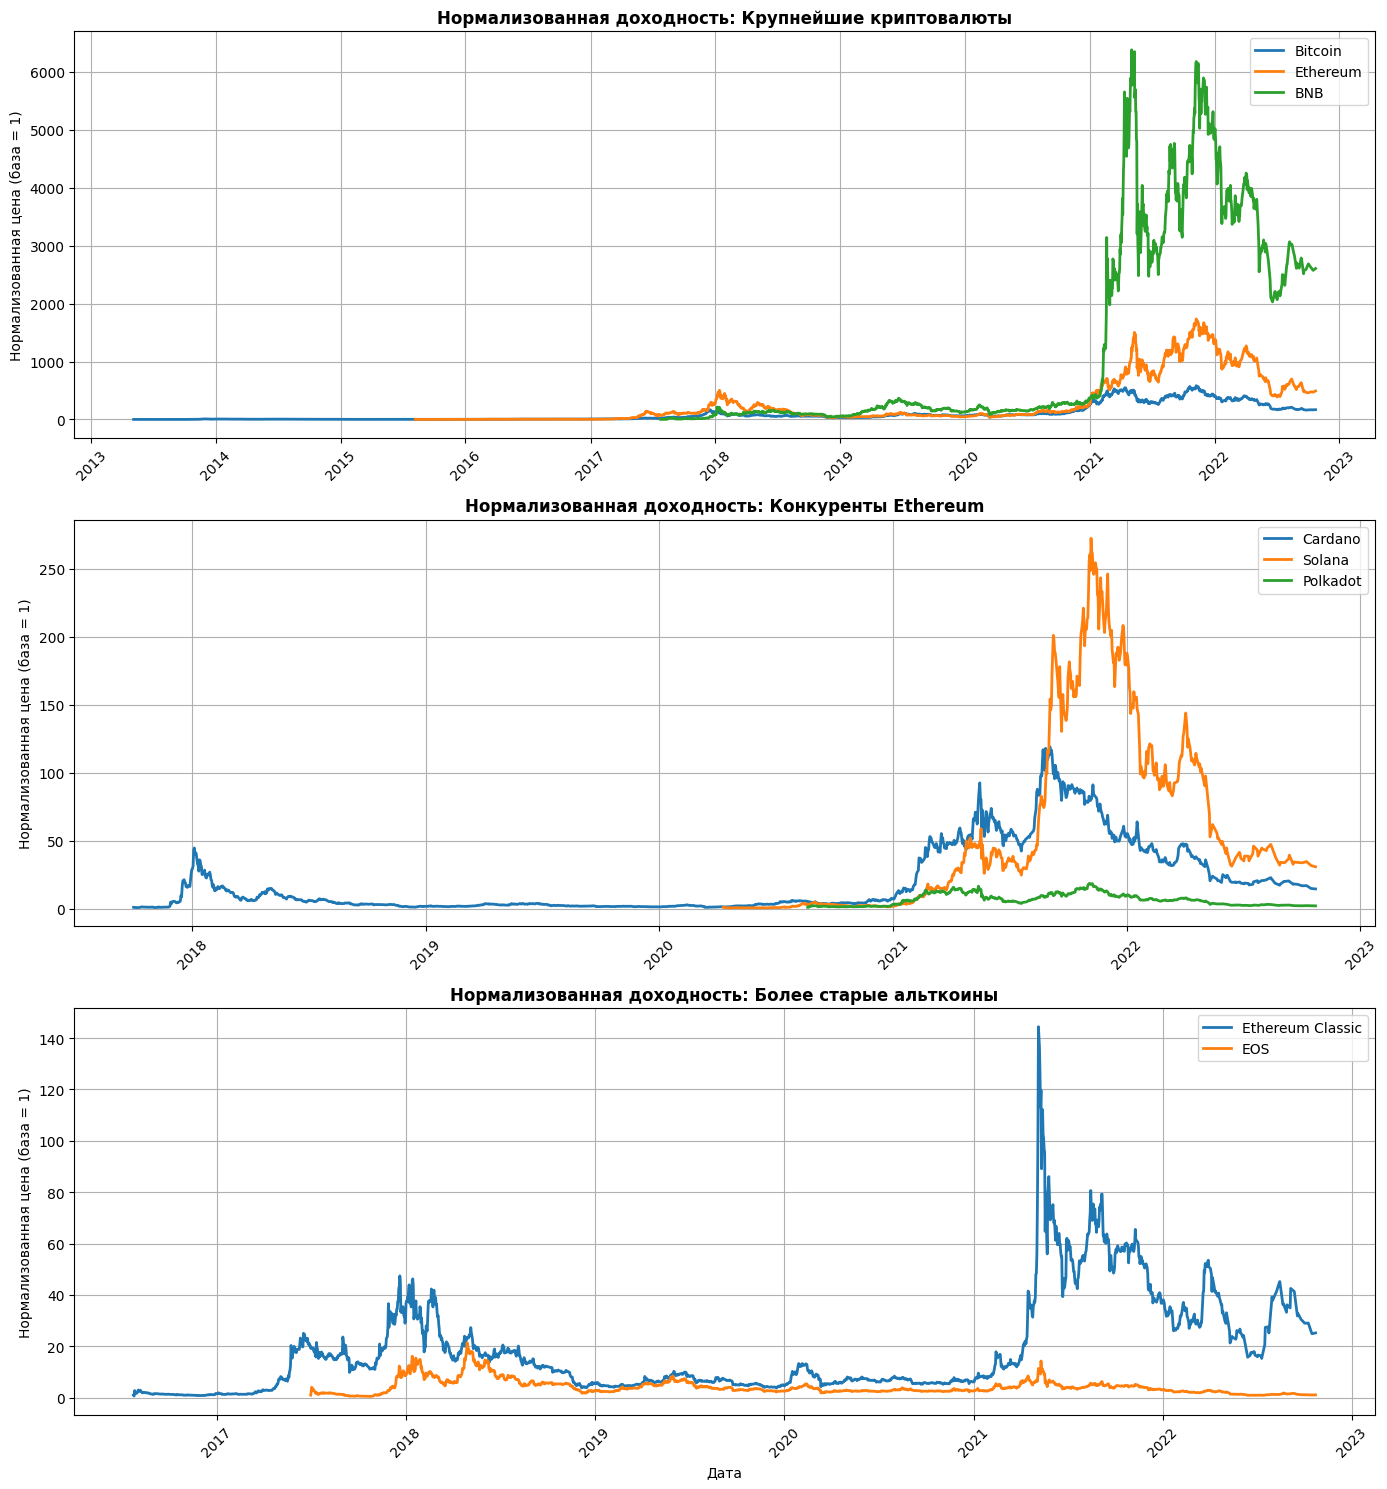

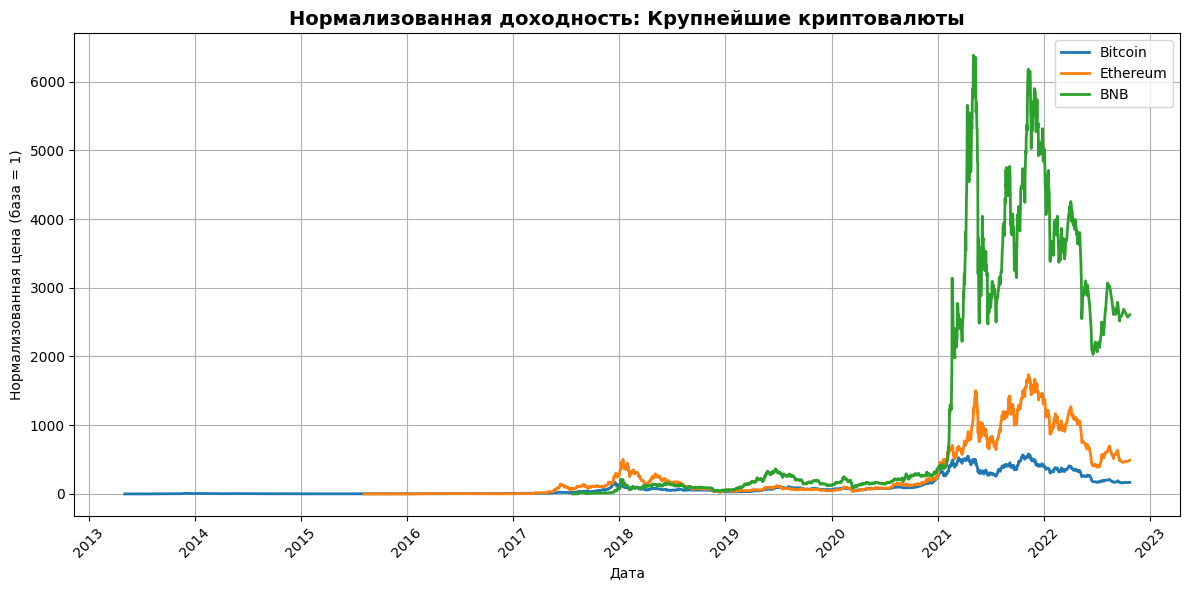

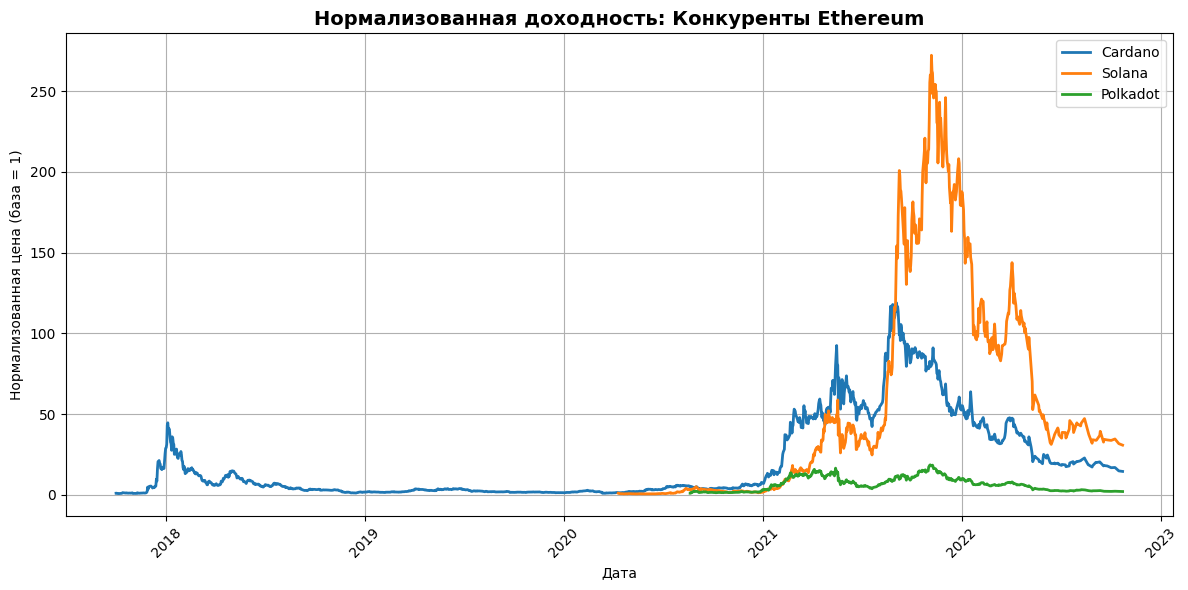

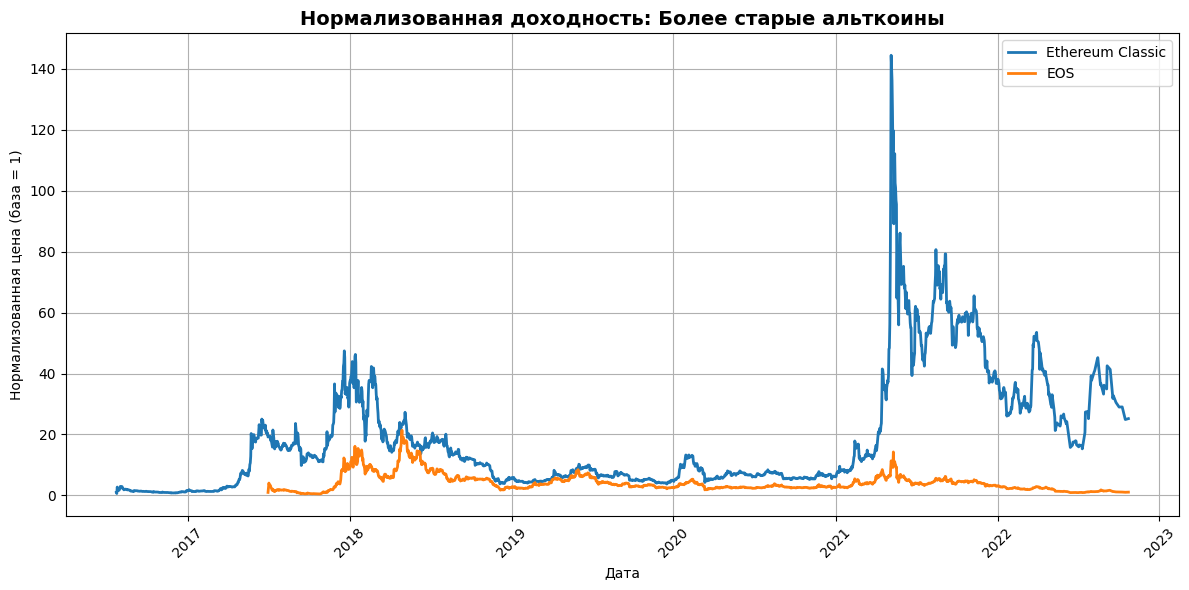

In [6]:
group_1 = ['Bitcoin', 'Ethereum', 'BNB']
group_2 = ['Cardano', 'Solana', 'Polkadot']
group_3 = ['Ethereum Classic', 'EOS']

groups = [group_1, group_2, group_3]
group_names = ['Крупнейшие криптовалюты', 'Конкуренты Ethereum', 'Более старые альткоины']

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for i, (group, name) in enumerate(zip(groups, group_names)):
    ax = axes[i]
    
    for crypto in group:
        crypto_data = df[df['crypto_name'] == crypto].sort_values('date')
        if len(crypto_data) > 0:
            normalized_price = crypto_data['close'] / crypto_data['close'].iloc[0]
            ax.plot(crypto_data['date'], normalized_price, label=crypto, linewidth=2)
    
    ax.set_title(f'Нормализованная доходность: {name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Нормализованная цена (база = 1)')
    ax.legend()
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)
plt.xlabel('Дата')
plt.tight_layout()
plt.show()

for i, (group, name) in enumerate(zip(groups, group_names)):
    plt.figure(figsize=(12, 6))
    
    for crypto in group:
        crypto_data = df[df['crypto_name'] == crypto].sort_values('date')
        if len(crypto_data) > 0:
            normalized_price = crypto_data['close'] / crypto_data['close'].iloc[0]
            plt.plot(crypto_data['date'], normalized_price, label=crypto, linewidth=2)
    
    plt.title(f'Нормализованная доходность: {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Дата')
    plt.ylabel('Нормализованная цена (база = 1)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()


Ethereum Classic и Ethereum демонстрируют наиболее стабильный рост с минимальными просадками. Это лидеры по доходности за период. Shiba Inu и Dogecoin показывают высокую волатильность с резкими взлетами и падениями.

построим график волатильности, который показывает стандартное отклонение доходностей и выявляет самые нестабильные активы

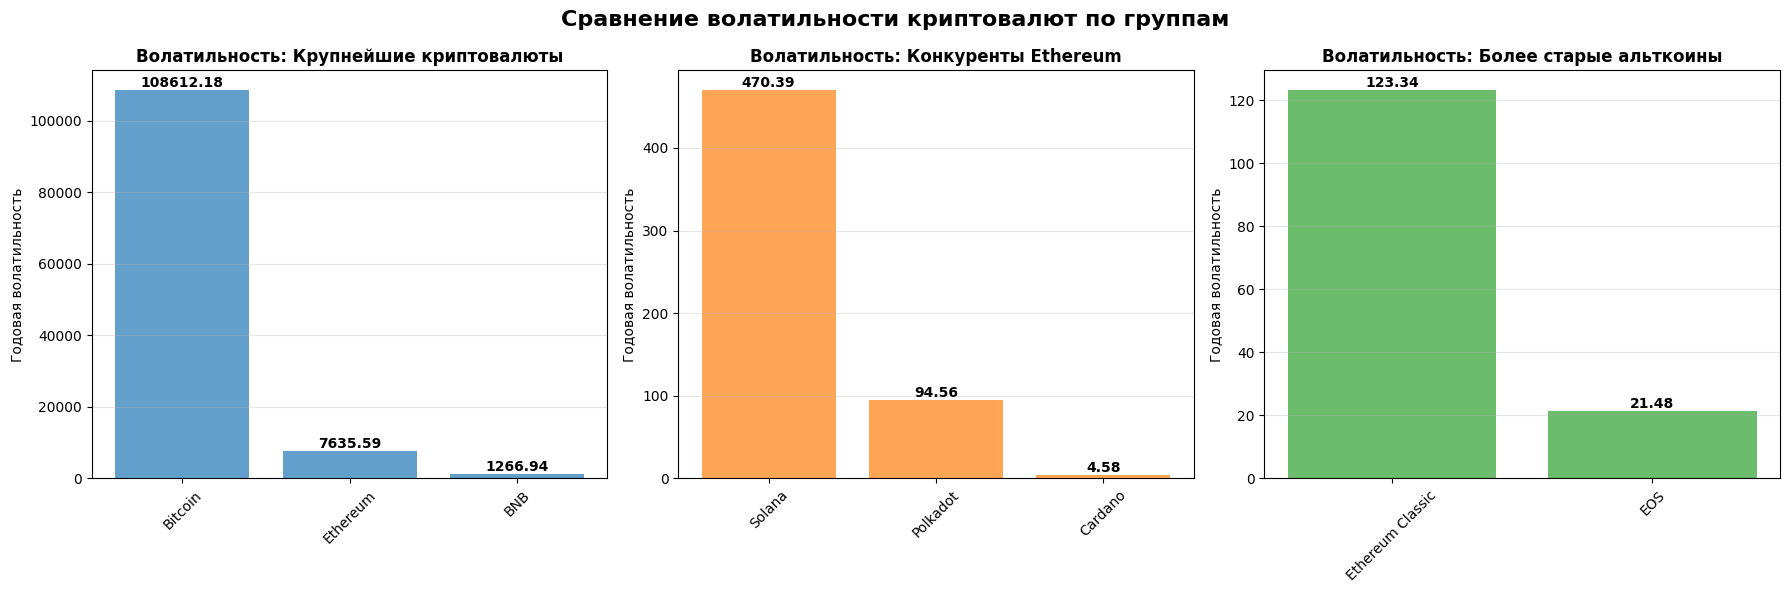

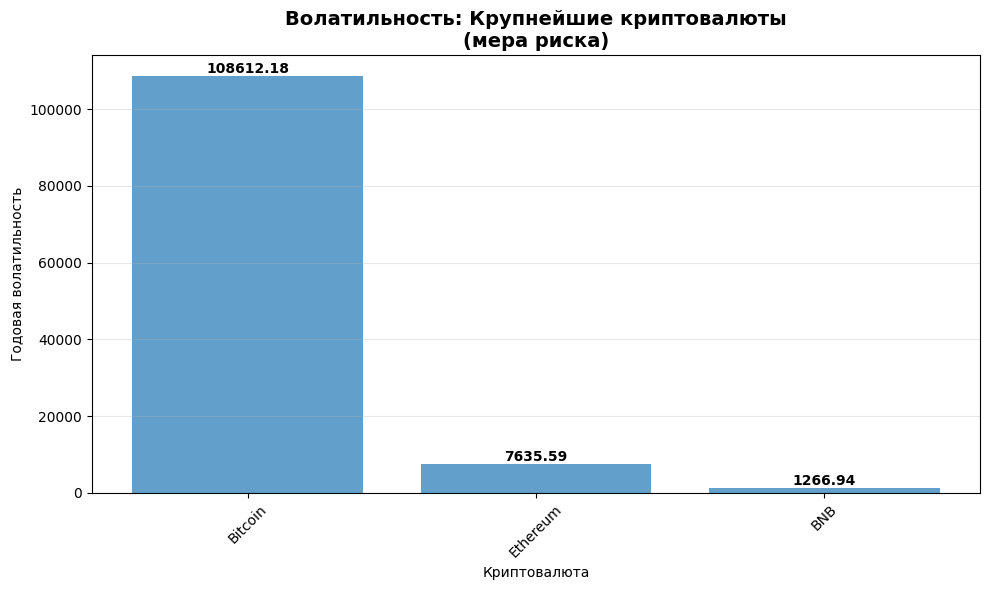

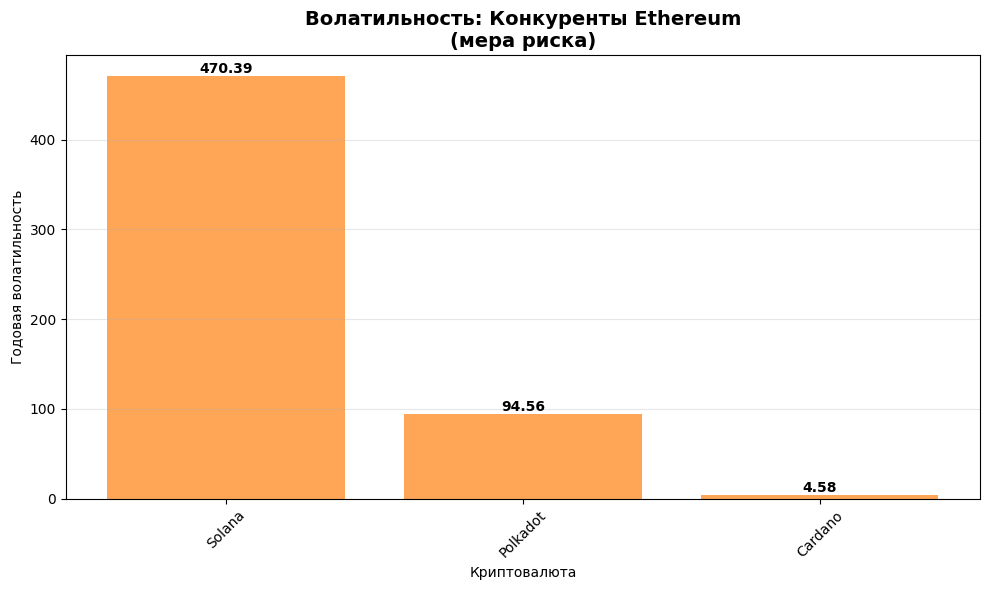

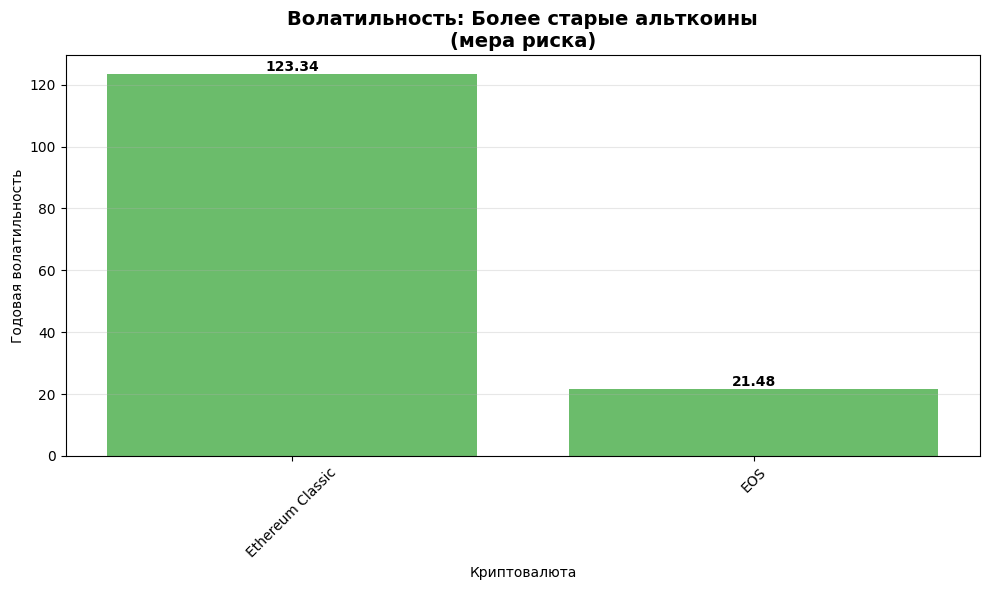

In [9]:
group_1 = ['Bitcoin', 'Ethereum', 'BNB']
group_2 = ['Cardano', 'Solana', 'Polkadot'] 
group_3 = ['Ethereum Classic', 'EOS'] 
groups = [group_1, group_2, group_3]
group_names = ['Крупнейшие криптовалюты', 'Конкуренты Ethereum', 'Более старые альткоины']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (group, name, color) in enumerate(zip(groups, group_names, colors)):
    volatility_data = []
    for crypto in group:
        crypto_data = df[df['crypto_name'] == crypto].sort_values('date')
        returns = crypto_data['close'].dropna()
        if len(returns) > 0:
            volatility = returns.std() * np.sqrt(52)
            volatility_data.append({'crypto_name': crypto, 'volatility': volatility})
    
    volatility_df = pd.DataFrame(volatility_data)
    volatility_df = volatility_df.sort_values('volatility', ascending=False)

    bars = axes[i].bar(volatility_df['crypto_name'], volatility_df['volatility'], 
                      color=color, alpha=0.7)

    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
    
    axes[i].set_title(f'Волатильность: {name}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Годовая волатильность')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Сравнение волатильности криптовалют по группам', fontsize=16, fontweight='bold')
plt.tight_layout()

for i, (group, name, color) in enumerate(zip(groups, group_names, colors)):
    plt.figure(figsize=(10, 6))
    volatility_data = []
    for crypto in group:
        crypto_data = df[df['crypto_name'] == crypto].sort_values('date')
        returns = crypto_data['close'].dropna()
        if len(returns) > 0:
            volatility = returns.std() * np.sqrt(52)
            volatility_data.append({'crypto_name': crypto, 'volatility': volatility})
    
    volatility_df = pd.DataFrame(volatility_data)
    volatility_df = volatility_df.sort_values('volatility', ascending=False)

    bars = plt.bar(volatility_df['crypto_name'], volatility_df['volatility'], 
                  color=color, alpha=0.7)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
    
    plt.title(f'Волатильность: {name}\n(мера риска)', fontsize=14, fontweight='bold')
    plt.xlabel('Криптовалюта')
    plt.ylabel('Годовая волатильность')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()

Shiba Inu - экстремальная волатильность
Aave - очень высокий риск
Decentraland - высокая нестабильность
Terra Classic - значительные колебания
The Sandbox - повышенный риск
Мем-коины (Shiba, Doge) и метавселенные (Decentraland, Sandbox) - наиболее рискованные активы.

построим график риск/доходность, который показывает эффективность - сколько дохода получаем за единицу риска, помогает выбрать между агрессивными и консервативными активами

BNB, Quant, Ethereum находятся в "золотой зоне" - предлагают хорошую доходность при относительно умеренном риске. Это оптимальный выбор для баланса риска и прибыли. Aave выделяется низкой доходностью, но очень высоким риском. Shiba Inu является самым рисковым и одновременно самым доходным.

построим график максимальных просадок, который выявляет восстановительную способность актива и какой максимальный убыток может понести инвестор

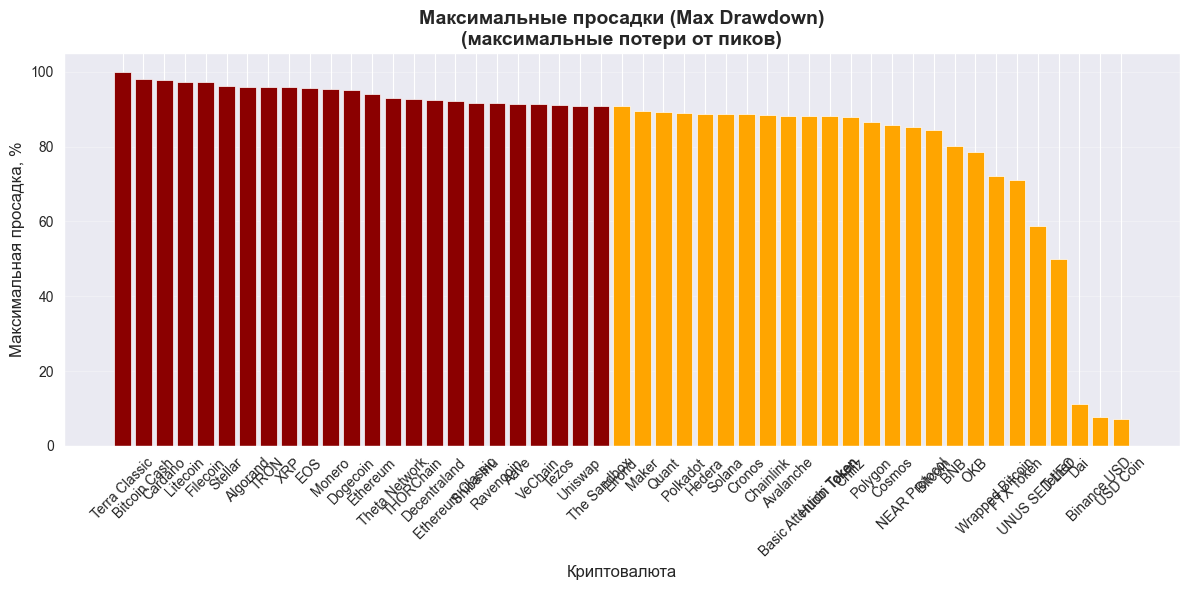

In [27]:
plt.figure(figsize=(12, 6))
drawdown_data = []
for crypto in cryptos:
    crypto_data = df[df['crypto_name'] == crypto].sort_values('date')
    prices = crypto_data['close'].values
    peak = prices[0]
    max_drawdown = 0
    for price in prices:
        if price > peak:
            peak = price
        drawdown = (peak - price) / peak * 100
        if drawdown > max_drawdown:
            max_drawdown = drawdown
    
    drawdown_data.append({'crypto_name': crypto, 'max_drawdown': max_drawdown})

drawdown_df = pd.DataFrame(drawdown_data)
drawdown_df = drawdown_df.sort_values('max_drawdown', ascending=False)

plt.bar(drawdown_df['crypto_name'], drawdown_df['max_drawdown'],
        color=['darkred' if x > drawdown_df['max_drawdown'].median() else 'orange' for x in drawdown_df['max_drawdown']])
plt.title('Максимальные просадки (Max Drawdown)\n(максимальные потери от пиков)', fontsize=14, fontweight='bold')
plt.xlabel('Криптовалюта')
plt.ylabel('Максимальная просадка, %')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

USD показывает наименьшие просадки, что свидетельствует о устойчивости. Shiba Inu и Terra Classic имеют экстремальные просадки (более 80%), что делает их очень рискованными.

построим график тепловая карта объемы/волатильность, который показывает интерес трейдеров к активу и Выявляет манипулируемые активы

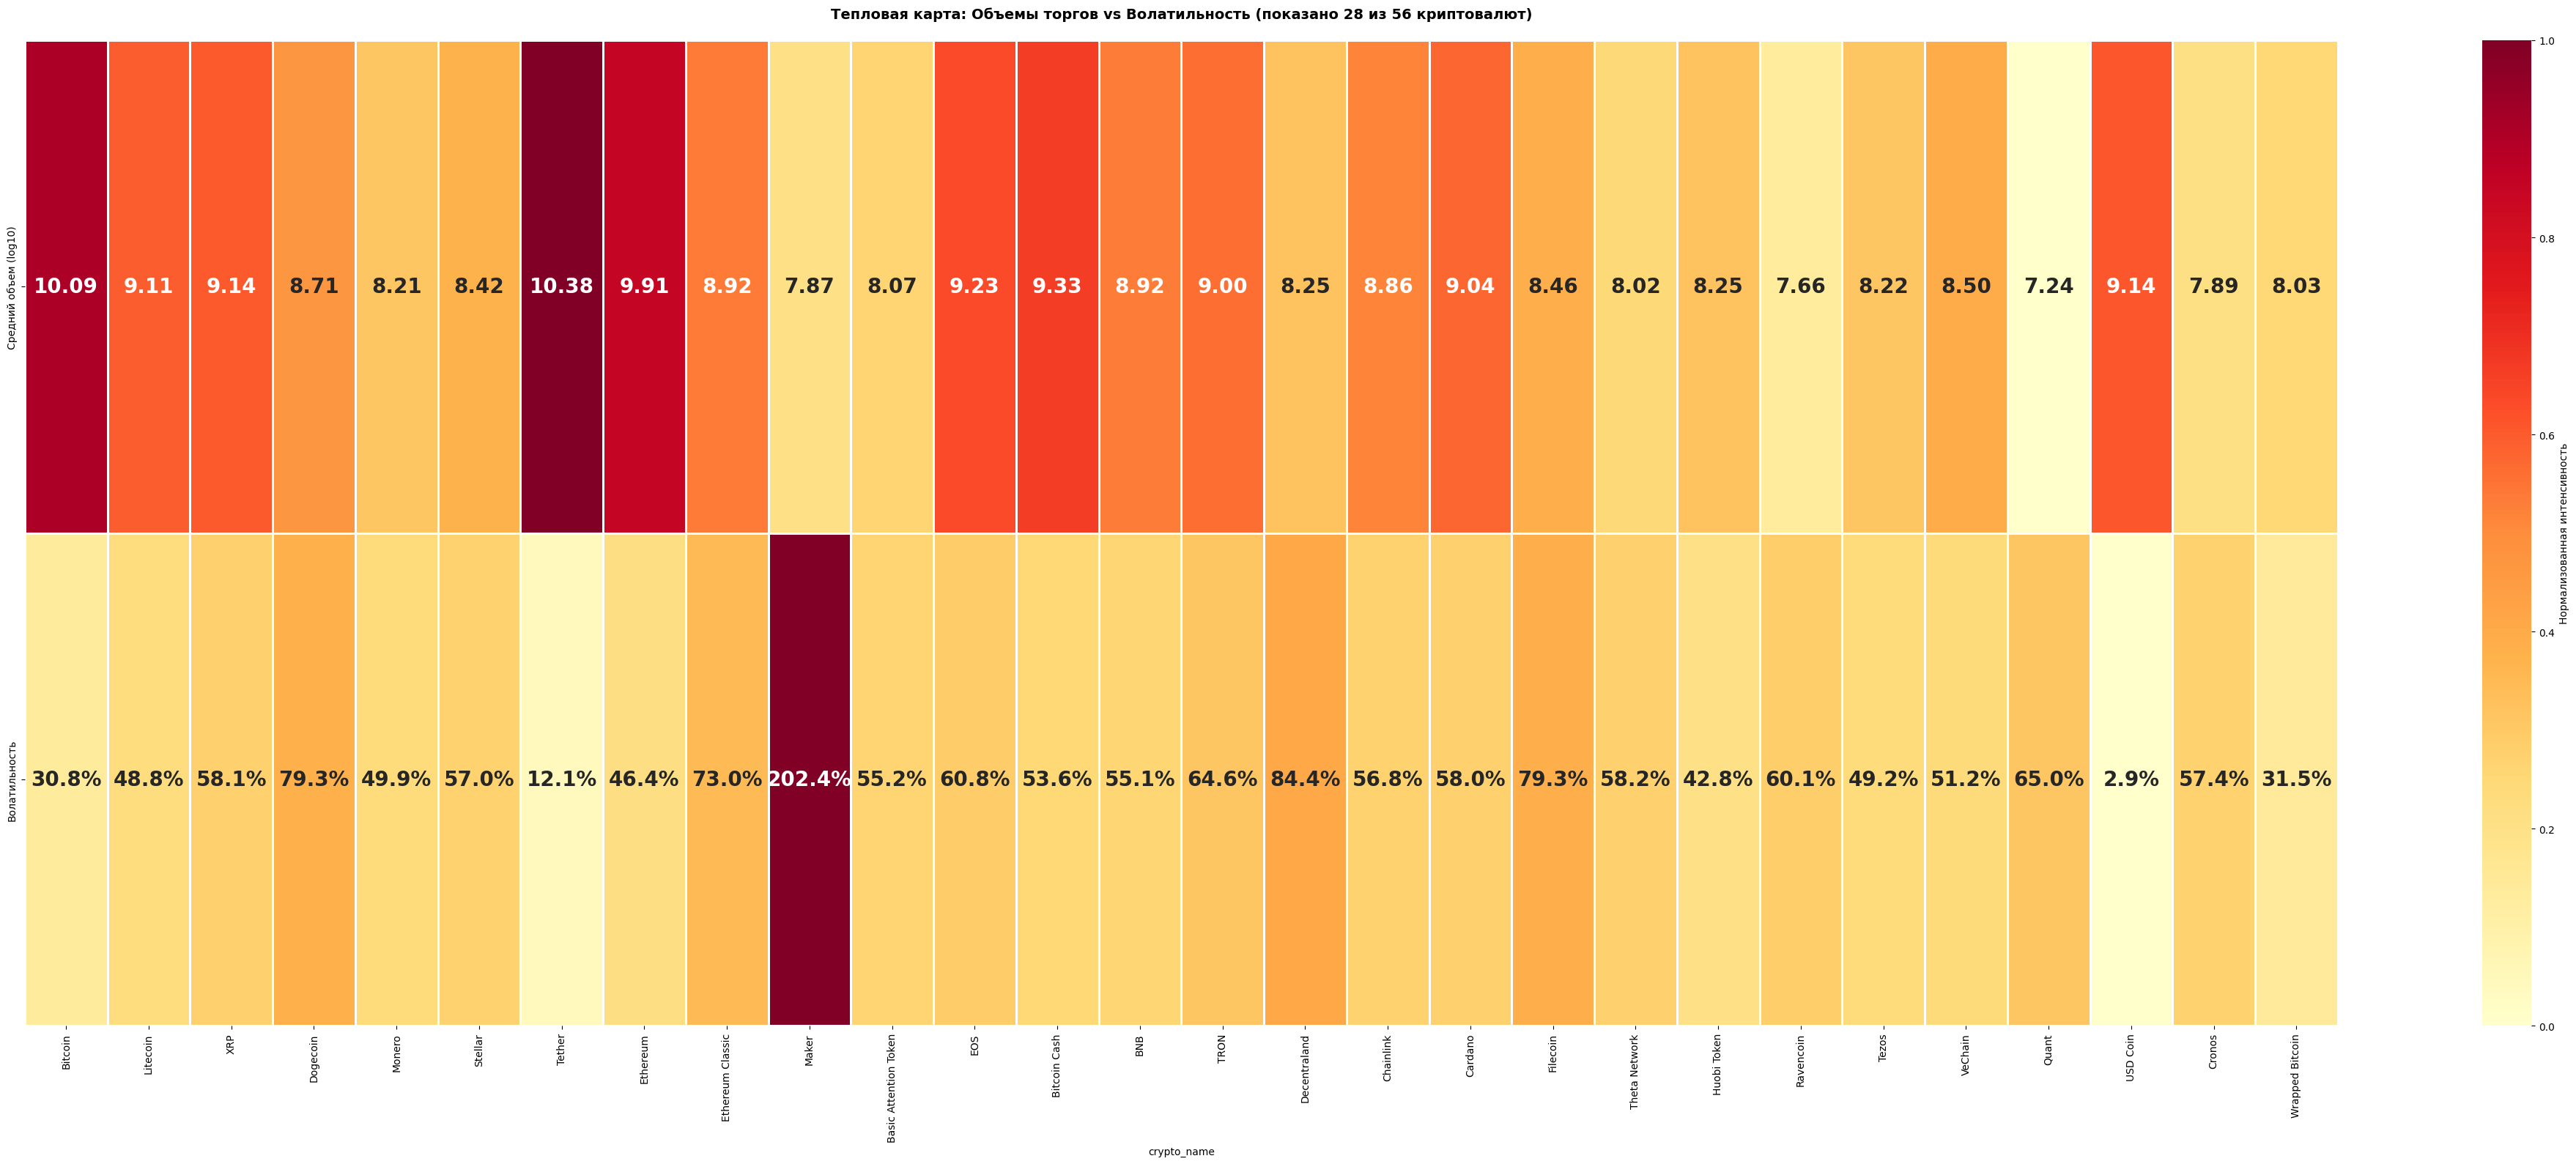

In [17]:
plt.figure(figsize=(40, 16))
volume_vol_data = []
for crypto in cryptos:
    crypto_data = df[df['crypto_name'] == crypto]
    avg_volume = crypto_data['volume'].mean()
    volatility = crypto_data['close'].pct_change().std() * np.sqrt(52) * 100
    
    volume_vol_data.append({
        'crypto_name': crypto,
        'avg_volume': np.log10(avg_volume),
        'volatility': volatility
    })

vv_df = pd.DataFrame(volume_vol_data)
pivot_data = vv_df.set_index('crypto_name')[['avg_volume', 'volatility']]
pivot_data.columns = ['Средний объем (log10)', 'Волатильность']

half_size = len(pivot_data) // 2
pivot_data_half = pivot_data.head(half_size) 

annotations = []
for i in range(len(pivot_data_half)):
    row_annotations = []
    for j in range(len(pivot_data_half.columns)):
        original_value = pivot_data_half.iloc[i, j]
        if j == 0:
            row_annotations.append(f"{original_value:.2f}")
        else:
            row_annotations.append(f"{original_value:.1f}%")
    annotations.append(row_annotations)

annotations = np.array(annotations).T
heatmap = sns.heatmap(pivot_data_normalized.T, 
            annot=annotations,
            cmap='YlOrRd',
            cbar_kws={'label': 'Нормализованная интенсивность'},
            linewidths=1,
            linecolor='white',
            annot_kws={'size': 20, 'weight': 'bold'},
            fmt='')
plt.title(f'Тепловая карта: Объемы торгов vs Волатильность (показано {len(pivot_data_half)} из {len(pivot_data)} криптовалют)\n', fontsize=14, fontweight='bold')
plt.tight_layout()

Ethereum сочетает высокие объемы торгов с умеренной волатильностью - признак зрелого актива. Shiba Inu и Aave имеют высокие объемы, но экстремальную волатильность - типично для спекулятивного актива.


построим график коэффициента Шарпа, который показывает доходность на единицу риска и позволяет сравнить эффективность управления риском

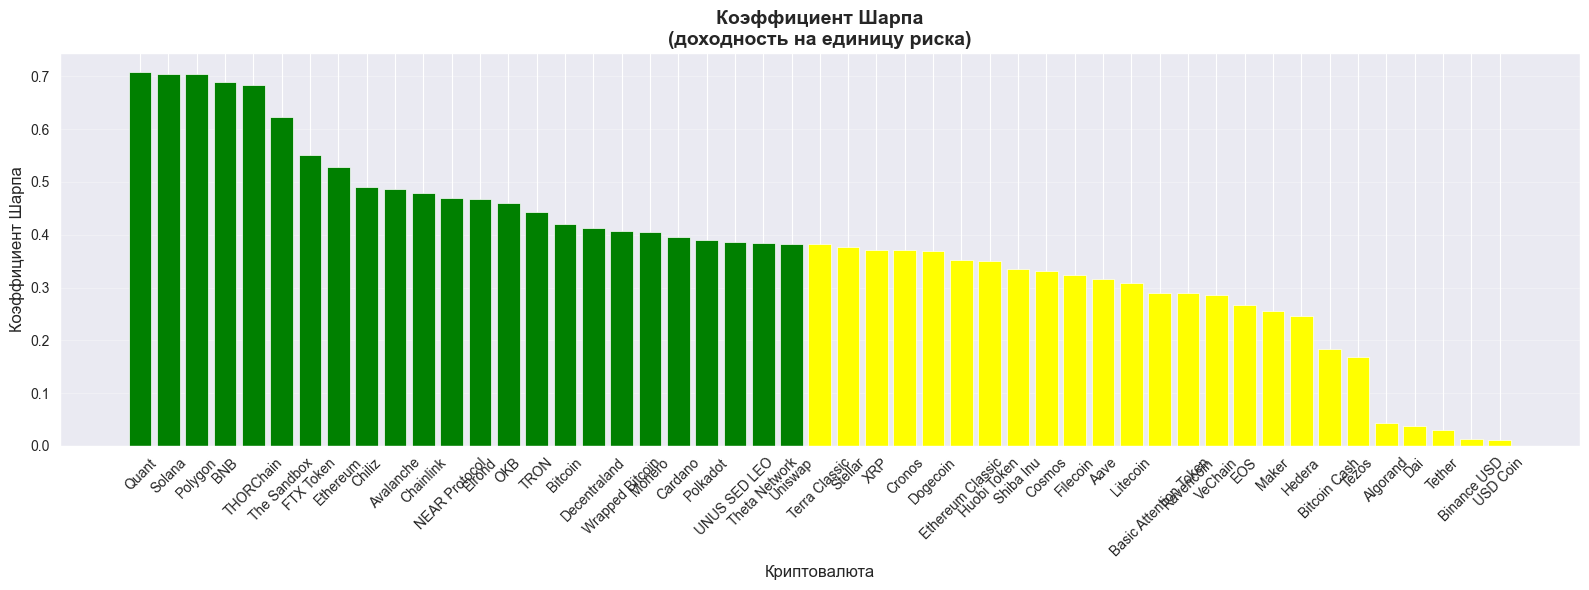

In [31]:
plt.figure(figsize=(16, 6))
sharpe_data = []
for crypto in cryptos:
    crypto_data = df[df['crypto_name'] == crypto].sort_values('date')
    returns = crypto_data['close'].pct_change().dropna()
    sharpe_ratio = returns.mean() / returns.std() * np.sqrt(52) if returns.std() > 0 else 0
    sharpe_data.append({'crypto_name': crypto, 'sharpe_ratio': sharpe_ratio})

sharpe_df = pd.DataFrame(sharpe_data)
sharpe_df = sharpe_df.sort_values('sharpe_ratio', ascending=False)

plt.bar(sharpe_df['crypto_name'], sharpe_df['sharpe_ratio'],
        color=['green' if x > sharpe_df['sharpe_ratio'].median() else 'yellow' for x in sharpe_df['sharpe_ratio']])
plt.title('Коэффициент Шарпа\n(доходность на единицу риска)', fontsize=14, fontweight='bold')
plt.xlabel('Криптовалюта')
plt.ylabel('Коэффициент Шарпа')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

Solana, Polygon, BNB и Quant демонстрируют лучшие показатели доходности на единицу риска. Это наиболее эффективные активы с точки зрения риск-менеджмента.

На основе анализа соотношения риск/доходность и вашего списка монет, вот расширенная инвестиционная классификация:

СБАЛАНСИРОВАННЫЕ ИНВЕСТИЦИИ (Оптимальное соотношение риск/доходность)

    Quant, Polygon, BNB - отличный баланс

    Chainlink, Cardano - устойчивый рост с умеренным риском

    Cosmos, Polkadot - технологически перспективные с хорошей стабильностью

    Elrond, Avalanche - современные блокчейны с растущим adoption



УМЕРЕННО-РИСКОВАННЫЕ (Потенциал выше среднего, но с контролируемым риском)

    Solana, NEAR Protocol - высокие технологии, но конкуренция

    Uniswap, ApeCoin - DeFi лидеры, зависят от рынка

    Filecoin, Theta Network - нишевые решения с потенциалом

    Internet Computer, Flow - инновационные, но недоказанные



ВЫСОКОРИСКОВАННЫЕ (Высокая волатильность, спекулятивный характер)

    Shiba Inu, Aave, Terra Classic

НАДЕЖНЫЕ АКТИВЫ (Низкий риск, стабильность)

    Bitcoin, Ethereum - фундамент рынка

    Ethereum Classic - проверенная временем

    Litecoin, Bitcoin Cash - устоявшиеся форки

    XRP, Stellar - платежные системы с партнерами



СТЕЙБЛКОИНЫ (Минимальный риск, сохранение капитала)

    Tether, USD Coin, Binance USD, Dai - практически нулевая волатильность